In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qutip import *

from benchmarks_circuit import (
    cat_state_circuit, gkp_state_circuit, JCH_simulation_circuit_display,JCH_simulation_circuit_unitary,
    binary_knapsack_vqe, binary_knapsack_vqe_circuit, shors_circuit, qft_circuit, state_transfer_CVtoDV,cv_qaoa,cv_qaoa_circuit
)
from features import (
    collect_cvcircuit_metrics, evaluate_quantum_metrics,
)
from shors_runner import *

from custom_gates import bosonic_vqe

import c2qa

## CAT State Circuit

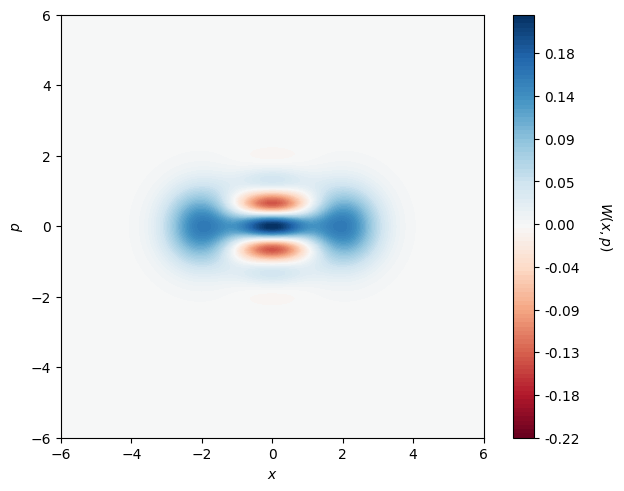

In [2]:
cutoff = 64
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(1)
circuit = c2qa.CVCircuit(qmr, qbr)
circuit = cat_state_circuit(cutoff, circuit, qbr, qmr, alpha=2)
state, _, _ = c2qa.util.simulate(circuit)

fig = c2qa.wigner.plot_wigner(circuit, state)

In [16]:
circuit.qregs

[QuantumRegister(6, 'qumode'), QuantumRegister(1, 'q1')]

/var/folders/1j/7k6yr_fx77jfgsb7qpnfj1w80000gn/T/ipykernel_8903/2251090382.py:6: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, cargs in circuit.data:


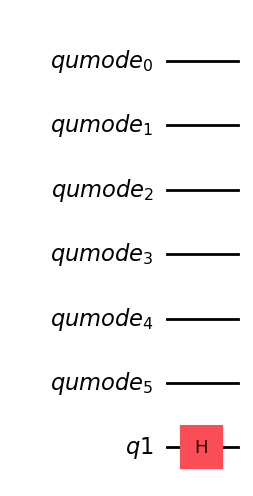

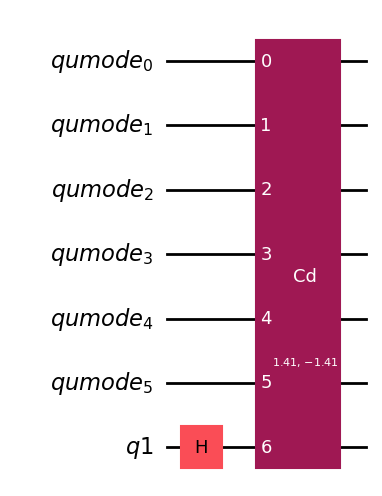

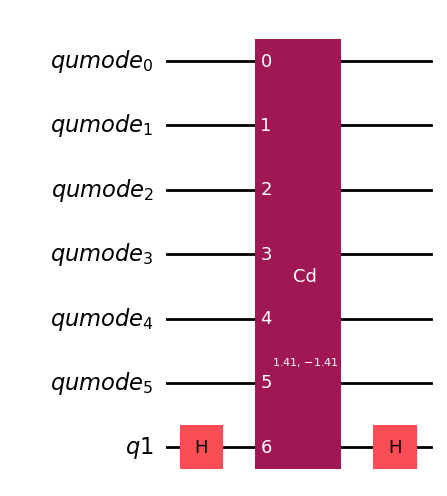

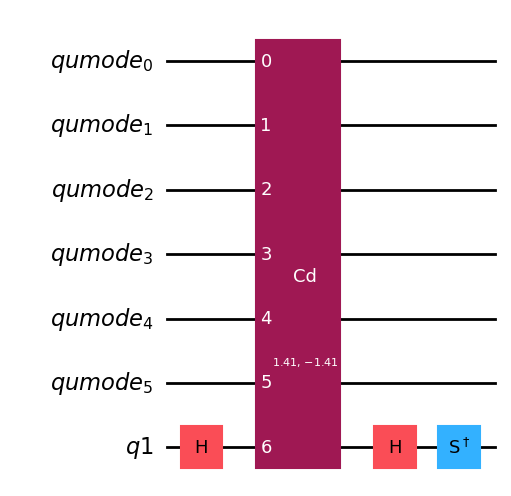

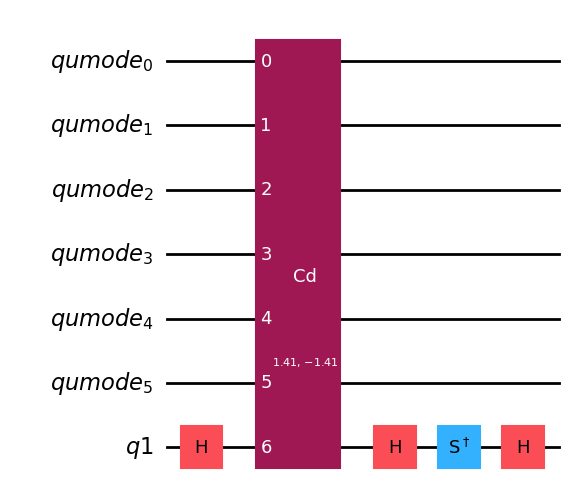

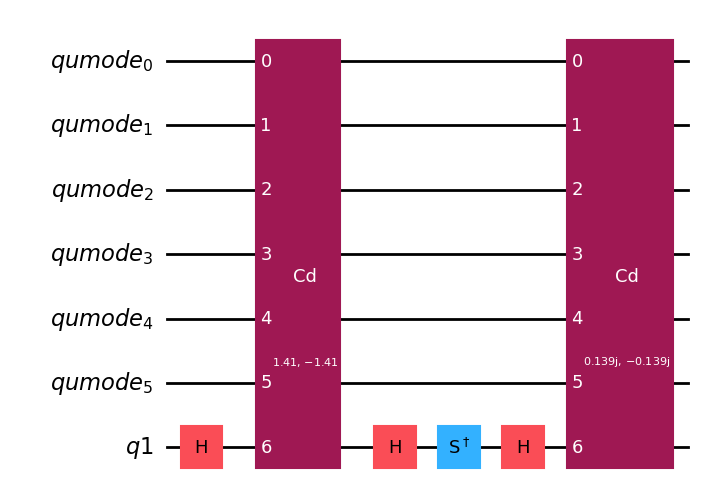

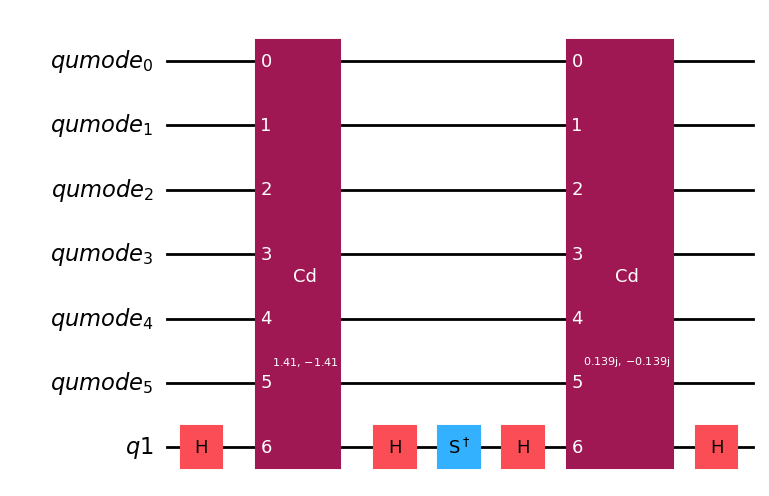

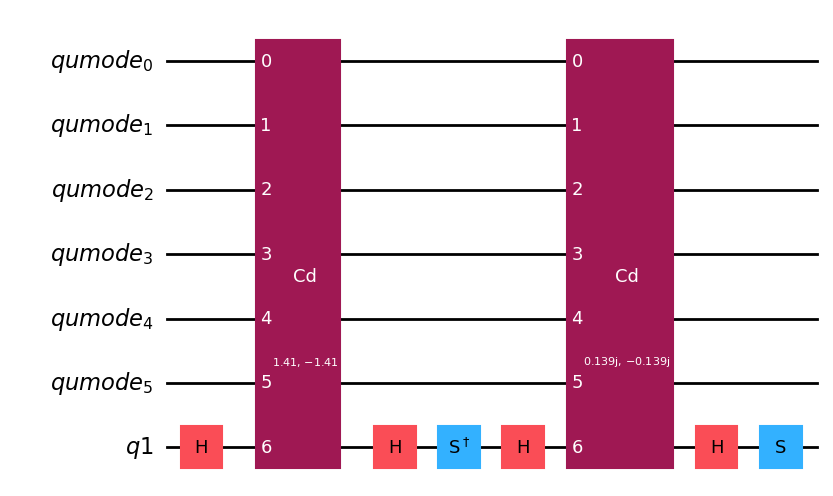

In [19]:
import copy

running_circuit = copy.deepcopy(circuit)
running_circuit.data=[]

for instr, qargs, cargs in circuit.data:
    running_circuit.append(instr, qargs, cargs)
    # state, _, _ = c2qa.util.simulate(running_circuit)
    display(running_circuit.draw('mpl'))

In [3]:
for i, gate in enumerate(circuit.gates):
    print(i,gate)

AttributeError: 'CVCircuit' object has no attribute 'gates'

In [ ]:
def max_energy_over_gates(circuit, cutoff, num_qumodes=1, num_qubits=1, omega_qumode=1.0, omega_qubit=1.0):
    """
    Compute maximum energy encountered after each gate in the circuit.
    """
    # Start with the initial state
    state, _, _ = c2qa.util.simulate(c2qa.CVCircuit(circuit.qumodes, circuit.qubits))
    max_energy = average_energy_all(state, num_qumodes, num_qubits, cutoff, omega_qumode, omega_qubit)

    # Apply gates one by one
    for i, gate in enumerate(circuit.gates):
        step_circuit = c2qa.CVCircuit(circuit.qumodes, circuit.qubits)
        step_circuit.gates = [gate]

        # Simulate this single gate starting from the current state
        state, _, _ = c2qa.util.simulate(step_circuit, initial_state=state)

        # Compute energy
        energy = average_energy_all(state, num_qumodes, num_qubits, cutoff, omega_qumode, omega_qubit)
        max_energy = max(max_energy, energy)

    return max_energy

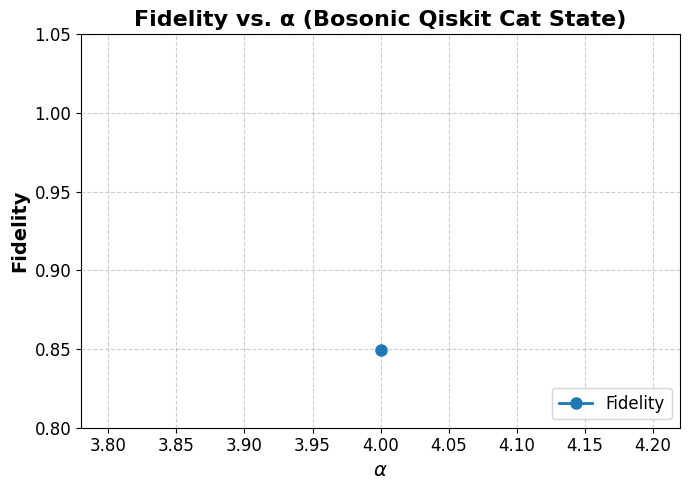

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import c2qa
from qiskit import QuantumRegister
from qiskit.quantum_info import state_fidelity
from qutip import coherent

cutoff = 64
alphas = [4]
fidelities = []

for alpha in alphas:
    # --- Generate Bosonic Qiskit cat state ---
    qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name="qumode")
    qbr = QuantumRegister(1)
    circuit = c2qa.CVCircuit(qmr, qbr)
    circuit = cat_state_circuit(cutoff, circuit, qbr, qmr, alpha=alpha)

    state, _, _ = c2qa.util.simulate(circuit)
    # fig = c2qa.wigner.plot_wigner(circuit, state)
    bq_state = c2qa.wigner.trace_out_qubits(circuit, state)

    # --- Generate Ideal Even Cat State using cv_initialize ---
    osc_init = coherent(cutoff, -alpha/np.sqrt(2)) + coherent(cutoff, alpha/np.sqrt(2))

    qmr_ref = c2qa.QumodeRegister(1, num_qubits_per_qumode=6)
    circuit_ref = c2qa.CVCircuit(qmr_ref)
    circuit_ref.cv_initialize(osc_init.full(), qmr_ref[0])

    state_ref, _, _ = c2qa.util.simulate(circuit_ref)
    # fig = c2qa.wigner.plot_wigner(circuit_ref, state_ref)
    reference_state = c2qa.wigner.trace_out_qubits(circuit_ref, state_ref)

    # --- Fidelity ---
    fid = state_fidelity(bq_state, reference_state)
    fidelities.append(fid)

plt.figure(figsize=(7, 5))

plt.plot(
    alphas,
    fidelities,
    marker="o",
    linestyle="-",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
    label="Fidelity",
)

plt.xlabel(r"$\alpha$", fontsize=14, fontweight="bold")
plt.ylabel("Fidelity", fontsize=14, fontweight="bold")
plt.title("Fidelity vs. α (Bosonic Qiskit Cat State)", fontsize=16, fontweight="bold")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0.8, 1.05)  # show up to 1

plt.legend(fontsize=12, frameon=True, loc="lower right")
plt.tight_layout()
plt.show()



In [23]:
print(fidelities)
print(alphas)

[0.9209221926156551, 0.6334522543103848, 0.41511492558311697, 0.22855903912800973, 0.10578952579636539, 0.04121791793354643]
[1 2 3 4 5 6]


## GKP Circuit

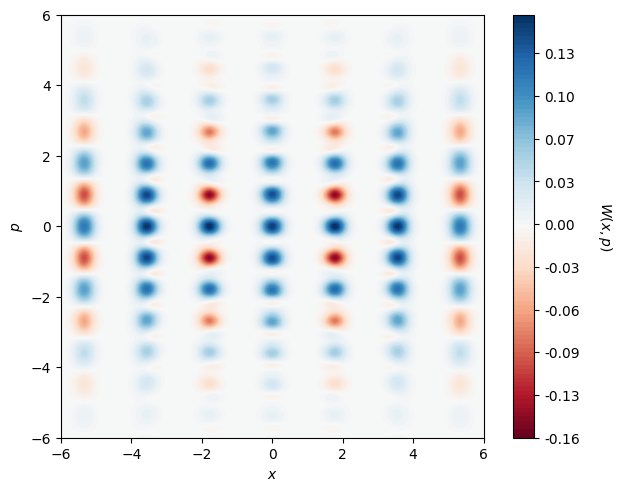

In [9]:
cutoff = 128
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=7, name='qumode')
qbr = QuantumRegister(1)
circuit = c2qa.CVCircuit(qmr, qbr)
circuit = gkp_state_circuit(cutoff, circuit, qbr, qmr,N_rounds=9,r=1.202)
state, _, _ = c2qa.util.simulate(circuit)

fig = c2qa.wigner.plot_wigner(circuit, state)

## State Transfer CV to DV

In [ ]:
cutoff = 64
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(4)
cr = ClassicalRegister(4)
circuit = c2qa.CVCircuit(qmr, qbr, cr)
circuit = state_transfer_CVtoDV(cutoff, circuit, qmr, qbr, cr, 4)

In [14]:
state, dv_dist, _ = c2qa.util.simulate(circuit)

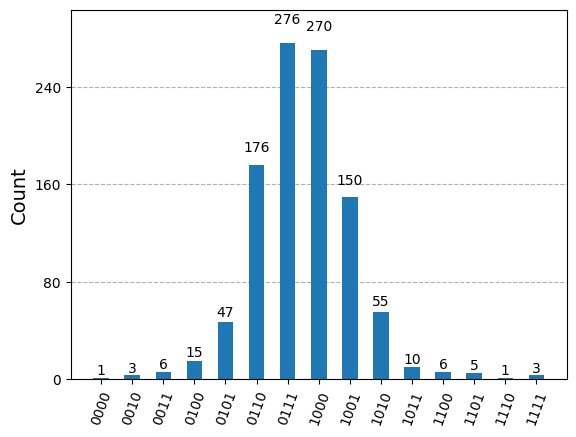

In [15]:
plot_histogram(dv_dist.get_counts())

## CV-DV QFT

In [16]:
circuit = qft_circuit(16, 1.1, 2, 1, 2)
state, dv_dist, _ = c2qa.util.simulate(circuit)

(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)


/home/smohapa5/Desktop/CV-DV-Benchmarking-/venv/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


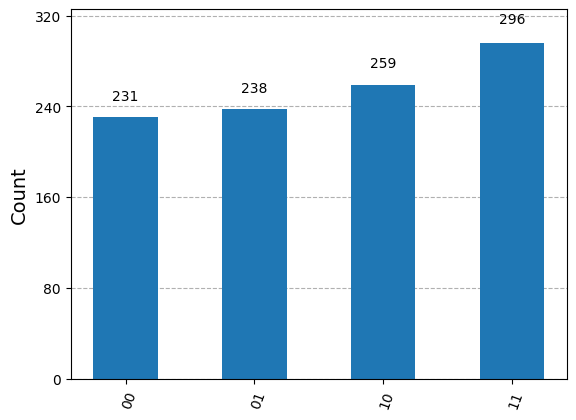

In [17]:
plot_histogram(dv_dist.get_counts())

## CV-DV VQE

In [46]:
values = [1, 4, 5, 10]
weights = [2.5, 1, 2, 3]
max_weight = 7
l_val = 3

nfocks = [8,8]
ndepth = 5

bkp_fun1, bkp_list1 = bosonic_vqe.binary_knapsack_ham(l_val, values, weights, max_weight)
bkp_list1 = bosonic_vqe.binary_to_pauli_list(bkp_fun1, bkp_list1)
bkp_ham1 = Qobj( bosonic_vqe.qubit_op_to_ham(bkp_list1).full() )

en, Xvec, int_results = binary_knapsack_vqe(bkp_ham1, ndepth, nfocks,  maxiter=120, method='BFGS',
                                    verb=1, threshold=1e-6)


/home/smohapa5/Desktop/CV-DV-Benchmarking-/custom_gates/bosonic_vqe_new.py:457: RuntimeWarning: Method BFGS cannot handle bounds.
  result = minimize(obj_fun, Xvec, method=method, bounds=bounds,


-------------------
iter: 10
fval: -1.2634343852112844
-------------------
iter: 20
fval: -4.057190987294748
-------------------
iter: 30
fval: -6.055186003677058
-------------------
iter: 40
fval: -10.889929180169682
-------------------
iter: 50
fval: -12.462811409568051
-------------------
iter: 60
fval: -15.094099147479493
-------------------
iter: 70
fval: -15.526049815545889
-------------------
iter: 80
fval: -15.748014044420737
-------------------
iter: 90
fval: -15.777081404647607
-------------------
iter: 100
fval: -15.77733272114234
-------------------
iter: 110
fval: -15.777345522770231
-------------------
iter: 120
fval: -15.778296414851596
         Current function value: -15.778296
         Iterations: 120
         Function evaluations: 5617
         Gradient evaluations: 137


/home/smohapa5/Desktop/CV-DV-Benchmarking-/venv/lib/python3.11/site-packages/scipy/optimize/_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [ ]:
P1 = bosonic_vqe.num_prob_all(Xvec,ndepth,nfocks)

## JCH Simulation

In [29]:
cutoff = 2**2
Nsites = 3
qmr = c2qa.QumodeRegister(Nsites, num_qubits_per_qumode=2)
qbr = QuantumRegister(Nsites)
circuit_template = c2qa.CVCircuit(qmr, qbr)
circuit_template.cv_initialize(2, qmr[0])
U1 = JCH_simulation_circuit_unitary(Nsites, Nqubits=Nsites, cutoff=cutoff,
                                        J=1, omega_r=2*np.pi*2, omega_q=2*np.pi*2,
                                        g=2*np.pi*0.5, tau=0.1)



In [ ]:
qmr = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))
qbr = QuantumRegister(3)
circuit = c2qa.CVCircuit(qmr,qbr)
circuit.cv_initialize(2, qmr[0])

tarray = np.arange(0, 50*0.1, 0.1)
occupancy_list = np.zeros((len(tarray),3))
i = 0
for tau in tarray:
    print('Timestep ' + str(int(i+1)) + '/' + str(len(tarray)))
    circuit.append(U1,qmr[:]+qbr[:])
    state, result, _ = c2qa.util.simulate(circuit)
    occupancy, _ = c2qa.util.stateread(state, 3,3,4, verbose=False,little_endian=False)
    occupancy_list[i,:]=np.array(occupancy[0])
    i = i+1

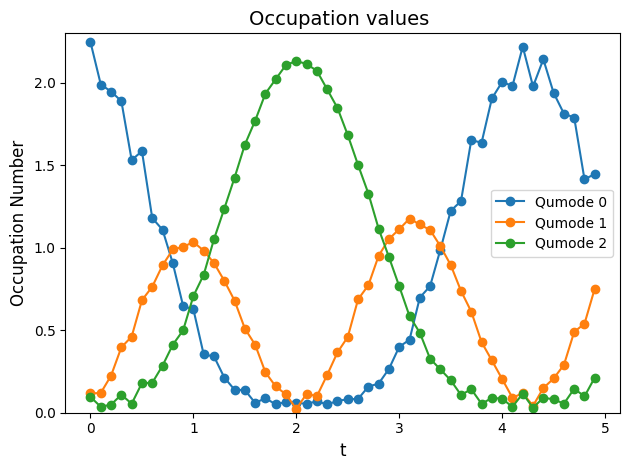

In [31]:
data1 = occupancy_list
time_steps = tarray

plt.plot(time_steps, data1[:, 0], label='Qumode 0', marker='o')  # Qumode 0
plt.plot(time_steps, data1[:, 1], label='Qumode 1', marker='o')  # Qumode 1
plt.plot(time_steps, data1[:, 2], label='Qumode 2', marker='o')  # Qumode 2
# plt.plot(time_steps, data1[:, 3], label='Qumode 3', marker='o')  # Qumode 3

plt.title('Occupation values ', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('Occupation Number', fontsize=12)
plt.ylim(0,2.3)

plt.legend()


plt.tight_layout()
plt.show()

## Shor's circuit

In [ ]:
settings = [(128, [15,21,35])]  #(cutoff,[numbers to factorise])

Ns = []
probabilities = []
labels = []

for cutoff, numbers in settings:
    for N in numbers:
        write_log(f"\n=== Running for N={N}, cutoff={cutoff} ===")
        success_rate, factors, total_successes, total_shots = estimate_success_probability(
                N=N, m=2, R=15, delta=1.202, cutoff=cutoff, trials=5, shots=1024
        )
        Ns.append(N)
        probabilities.append(success_rate)
        label = ', '.join(map(str, factors)) if factors else "None"
        labels.append(label)

4
2
4
8
4
2
1
11
4
13
4
2
16
10
1
13
4
2
1
13
1
29
29
8
16
31
29
22
16
31


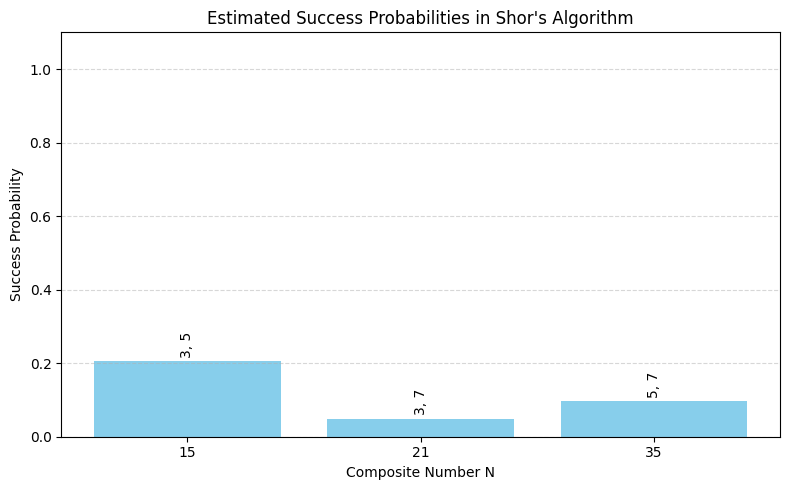

In [45]:
plt.figure(figsize=(8, 5))
bars = plt.bar([str(N) for N in Ns], probabilities, color='skyblue')

# Annotate each bar with its factors (as label)
for bar, label in zip(bars, labels):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, label,
             ha='center', va='bottom', fontsize=10, rotation=90)

plt.title("Estimated Success Probabilities in Shor's Algorithm")
plt.xlabel("Composite Number N")
plt.ylabel("Success Probability")
plt.ylim(0, 1.1)  # y-axis from 0 to slightly above 1
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()